In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
uber = pd.read_csv("UberDataset.csv")
uber.head()

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [ ]:
uber.shape
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1156 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1156 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


# **DATA PREPROSESSING**

In [ ]:
uber['PURPOSE'].fillna("N/A", inplace=True)

/tmp/ipykernel_433/3570947918.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  uber['PURPOSE'].fillna("N/A", inplace=True)


added the 'PURPOSE' table as it had null and missing values. Instead of staying empty, we filled the missing values with N/A

In [ ]:
uber.head(5)  #Verifying if the changes have taken effect

,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,N/A
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [ ]:
uber['START_DATE'] = pd.to_datetime(uber['START_DATE'],
                                       errors='coerce')
uber['END_DATE'] = pd.to_datetime(uber['END_DATE'],
                                     errors='coerce')
#Changing START_DATE and END_DATE into a singluar date format
from datetime import datetime

uber['date'] = pd.DatetimeIndex(uber['START_DATE']).date
uber['time'] = pd.DatetimeIndex(uber['START_DATE']).hour


uber['day-night'] = pd.cut(x=uber['time'],
                              bins = [0,10,15,19,24],
                              labels = ['Morning','Afternoon','Evening','Night'])
# Changing DATE and TIME to specfifc keywords like Morninig, Afternoon, Evening
# and Night for more of understandable format during data visualisation

In [ ]:
uber.dropna(inplace=True) #Removing NULL values
uber.drop_duplicates(inplace=True) #Removing duplicate data

# **DATA VISUALISATION**

/tmp/ipykernel_433/999532032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(uber['CATEGORY'], palette='Set2')
/tmp/ipykernel_433/999532032.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(uber['PURPOSE'], palette='muted')


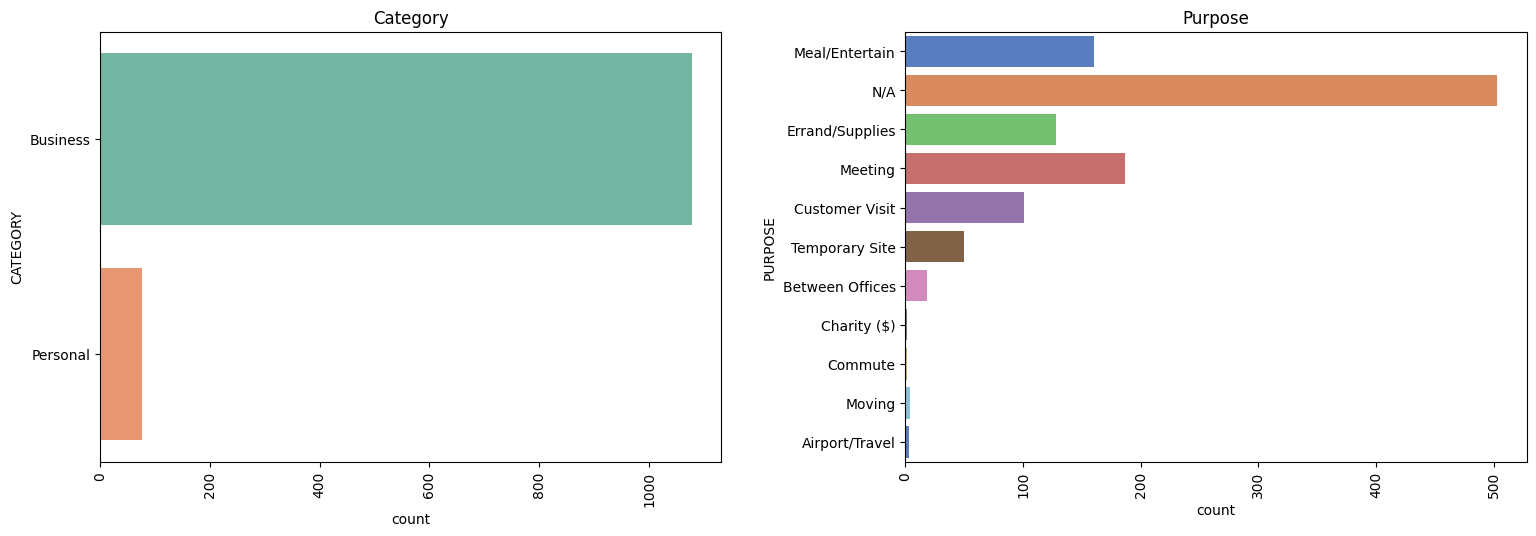

In [ ]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.countplot(uber['CATEGORY'], palette='Set2')
plt.xticks(rotation=90)
plt.title('Category')

plt.subplot(1, 2, 2)
sns.countplot(uber['PURPOSE'], palette='muted')
plt.xticks(rotation=90)
plt.title('Purpose')

plt.tight_layout(pad=3.0)
plt.show()

**Key insights:**

Business trips dominate massively — the Business bar is many times longer than Personal, meaning this Uber account is used almost entirely for work

N/A is the most common purpose — many trips had no purpose recorded, which could suggest they were personal or unlogged

Meetings and Meal/Entertainment are the top recorded business purposes, which makes sense for a corporate account

Between Offices, Charity, Moving are very rare — these are one-off or occasional trip types

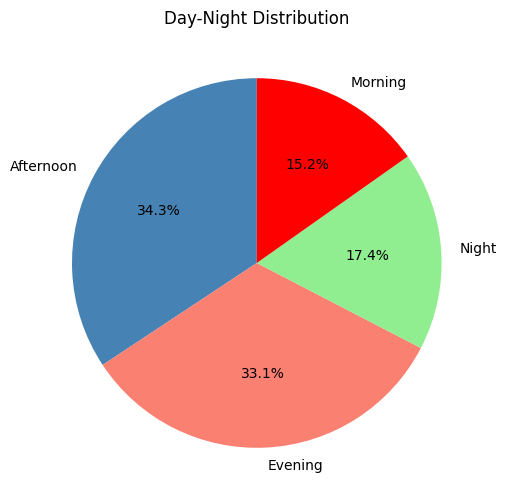

In [ ]:
# Count the values first
counts = uber['day-night'].value_counts()

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts,
        labels=counts.index,
        autopct='%1.1f%%',        # shows percentage on each slice
        colors=['steelblue', 'salmon', 'lightgreen', 'red'],
        startangle=90)

plt.title('Day-Night Distribution')
plt.show()

**Key insights:**

Afternoon (34.3%) is the busiest period — likely post-lunch meetings, client visits, or commutes
Evening (33.1%) is almost equally busy — suggests work dinners, late meetings, or end-of-day travel
Night (17.4%) — a notable chunk of trips happen late, possibly airport runs or after-hours events
Morning (15.2%) is the quietest — fewer early trips compared to the rest of the day

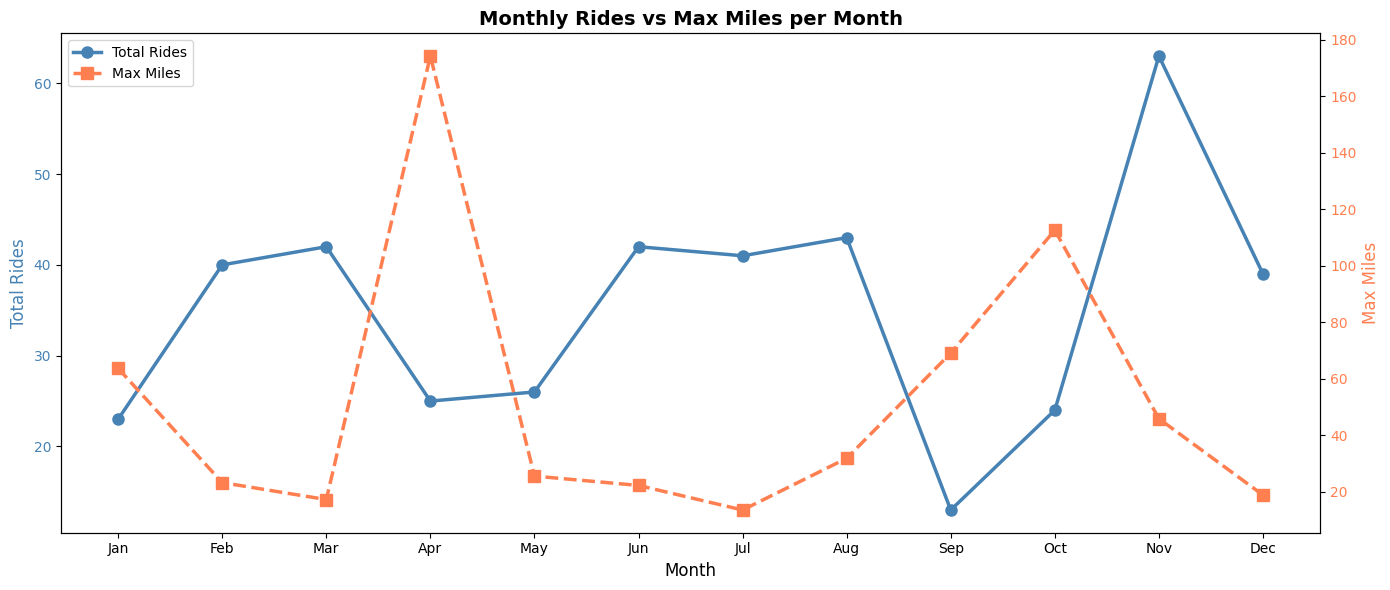

In [ ]:
uber['MONTH'] = pd.DatetimeIndex(uber['START_DATE']).month
month_label = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
               5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
               9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
uber['MONTH'] = uber['MONTH'].map(month_label)

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

mon = uber['MONTH'].value_counts()
max_miles = uber.groupby('MONTH', sort=False)['MILES'].max()

df = pd.DataFrame({
    'Total Rides': mon,
    'Max Miles': max_miles
}).reindex(month_order).dropna()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Line 1 - Total Rides
ax1.plot(df.index, df['Total Rides'], marker='o', color='steelblue',
         linewidth=2.5, markersize=8, label='Total Rides')
ax1.set_ylabel('Total Rides', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line 2 - Max Miles on second axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['Max Miles'], marker='s', color='coral',
         linewidth=2.5, markersize=8, linestyle='--', label='Max Miles')
ax2.set_ylabel('Max Miles', color='coral', fontsize=12)
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_xlabel('Month', fontsize=12)
plt.title('Monthly Rides vs Max Miles per Month', fontsize=14, fontweight='bold')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Key insights:**

Ride volume peaks around October–November — could reflect a busier business period or end-of-year travel

Max Miles spikes dramatically in April — one extremely long trip was recorded that month (possibly an airport or inter-city trip), which stands out as an outlier

The two lines move independently — a high-ride month doesn't always mean long trips, and vice versa

January and December are quieter — likely holiday periods with less business activity

<Axes: xlabel='DURATION', ylabel='Count'>

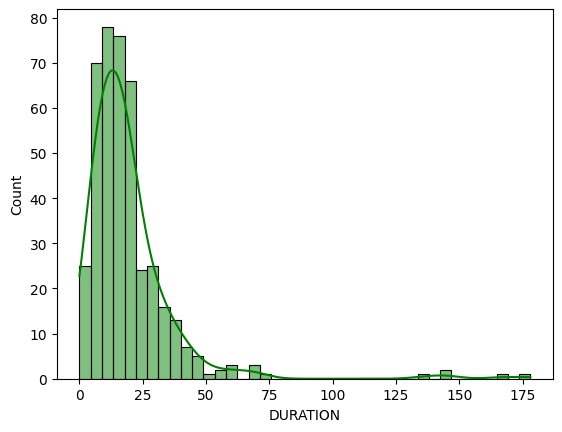

In [ ]:
uber['DURATION'] = (pd.to_datetime(uber['END_DATE']) -
                       pd.to_datetime(uber['START_DATE'])).dt.total_seconds() / 60
sns.histplot(uber['DURATION'], bins=40, kde=True, color='green')

**Key insights:**

The vast majority of trips are under 30 minutes — most rides are short, local journeys

The distribution is heavily right-skewed — a small number of very long trips (150+ mins) pull the tail out

The peak is around 5–15 minutes, confirming most trips are quick point-to-point rides

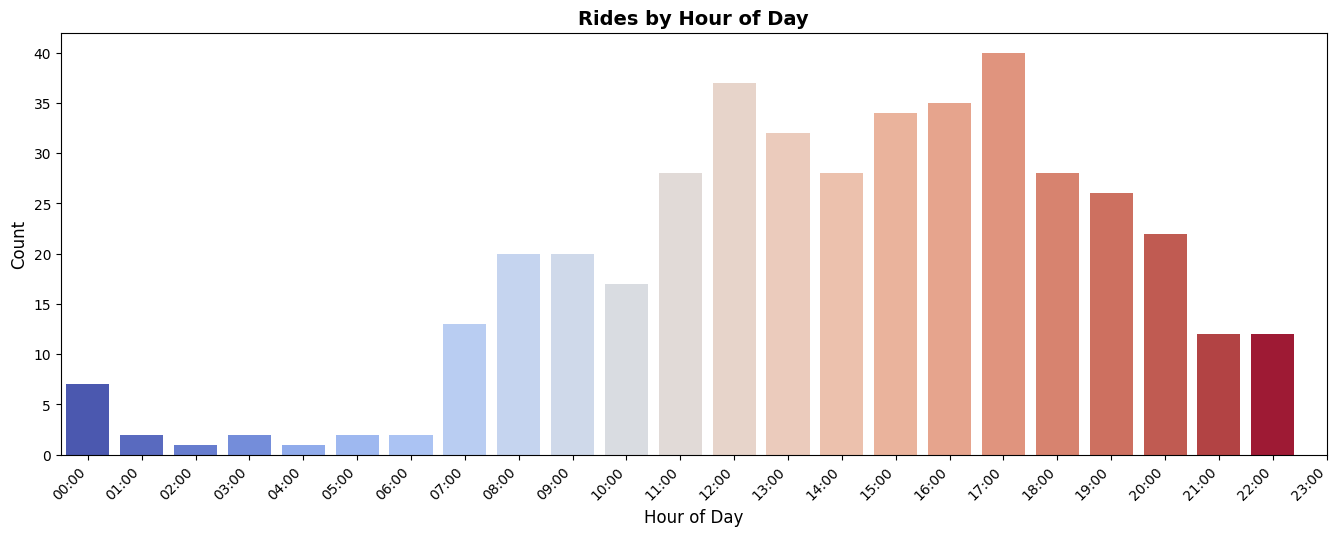

In [ ]:
uber['HOUR'] = pd.to_datetime(uber['START_DATE']).dt.hour

plt.figure(figsize=(14, 6))  # wider figure
sns.countplot(data=uber, x='HOUR', palette='coolwarm', hue='HOUR', legend=False)
plt.title('Rides by Hour of Day', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=range(24), labels=[f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout(pad=3.0)
plt.show()

**Key insights:**

Dead quiet from 01:00–07:00 — almost no trips in the early morning, which makes sense for a business account

Activity picks up sharply at 08:00–09:00 — the start of the working day

Peak hour is 17:00 (5pm) with 40 trips — classic evening rush hour / end of workday

Strong activity from 11:00–18:00 — the entire working day is busy

Drops off after 20:00 — less travel in late evening

Small spike at 00:00 — possibly late-night airport or event trips